In [ ]:
import os



import numpy as np



import matplotlib.pyplot as plt



from tensorflow.keras.preprocessing.image import ImageDataGenerator



from tensorflow.keras.models import Sequential



from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout



from tensorflow.keras.optimizers import Adam



from sklearn.model_selection import train_test_split



from tensorflow.keras.utils import to_categorical



from tensorflow.keras.preprocessing import image



from tensorflow.keras.applications import VGG16, ResNet50, MobileNet



from tensorflow.keras.layers import GlobalAveragePooling2D



from tensorflow.keras import Model



from sklearn.metrics import classification_report, confusion_matrix, accuracy_score







# Step 1: Load and Preprocess the Images



data_dir = '/content/braintumour'



categories = ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']



img_size = 150







data = []



labels = []







for category in categories:



    path = os.path.join(data_dir, category)



    class_num = categories.index(category)



    for img in os.listdir(path):



        try:



            img_array = image.load_img(os.path.join(path, img), target_size=(img_size, img_size))



            img_array = image.img_to_array(img_array) / 255.0  # Normalize pixel values



            data.append(img_array)



            labels.append(class_num)



        except Exception as e:



            print(f"Error loading image {img}: {e}")







# Convert lists to numpy arrays



data = np.array(data)



labels = np.array(labels)







# Step 2: Train-Test Split and One-Hot Encoding for CNN



X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)



y_train = to_categorical(y_train, num_classes=len(categories))



y_test = to_categorical(y_test, num_classes=len(categories))







# Step 3: Data Augmentation



datagen = ImageDataGenerator(



    rotation_range=10,



    width_shift_range=0.1,



    height_shift_range=0.1,



    zoom_range=0.1,



    horizontal_flip=True



)







# Step 4: Define CNN Model



cnn_model = Sequential([



    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),



    MaxPooling2D((2, 2)),



    Conv2D(64, (3, 3), activation='relu'),



    MaxPooling2D((2, 2)),



    Conv2D(128, (3, 3), activation='relu'),



    MaxPooling2D((2, 2)),



    Flatten(),



    Dense(128, activation='relu'),



    Dropout(0.5),



    Dense(len(categories), activation='softmax')



])



cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])







# Step 5: Transfer Learning Models







def create_transfer_model(base_model):



    base_model.trainable = False  # Freeze base model layers



    model = Sequential([



        base_model,



        GlobalAveragePooling2D(),



        Dense(128, activation='relu'),



        Dropout(0.5),



        Dense(len(categories), activation='softmax')



    ])



    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])



    return model







# VGG16



vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))



vgg16_model = create_transfer_model(vgg16_base)







# ResNet50



resnet50_base = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))



resnet50_model = create_transfer_model(resnet50_base)







# MobileNet



mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))



mobilenet_model = create_transfer_model(mobilenet_base)







# Step 6: Train and Evaluate Models



batch_size = 32



epochs = 10  # Reduced for quicker comparison







# Train CNN



history_cnn = cnn_model.fit(



    datagen.flow(X_train, y_train, batch_size=batch_size),



    validation_data=(X_test, y_test),



    steps_per_epoch=len(X_train) // batch_size,



    epochs=epochs



)







# Train VGG16



history_vgg16 = vgg16_model.fit(



    datagen.flow(X_train, y_train, batch_size=batch_size),



    validation_data=(X_test, y_test),



    steps_per_epoch=len(X_train) // batch_size,



    epochs=epochs



)







# Train ResNet50



history_resnet50 = resnet50_model.fit(



    datagen.flow(X_train, y_train, batch_size=batch_size),



    validation_data=(X_test, y_test),



    steps_per_epoch=len(X_train) // batch_size,



    epochs=epochs



)







# Train MobileNet



history_mobilenet = mobilenet_model.fit(



    datagen.flow(X_train, y_train, batch_size=batch_size),



    validation_data=(X_test, y_test),



    steps_per_epoch=len(X_train) // batch_size,



    epochs=epochs



)







# Step 7: Model Evaluation



def evaluate_model(model, name):



    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)



    print(f"{name} Test Accuracy: {test_accuracy * 100:.2f}%")



    y_pred = model.predict(X_test)



    y_pred_classes = np.argmax(y_pred, axis=1)



    y_true = np.argmax(y_test, axis=1)



    print("Classification Report:")



    print(classification_report(y_true, y_pred_classes, target_names=categories))



    print("Confusion Matrix:")



    print(confusion_matrix(y_true, y_pred_classes))







# Evaluate all models



print("\nEvaluating CNN Model:")



evaluate_model(cnn_model, "CNN")







print("\nEvaluating VGG16 Model:")



evaluate_model(vgg16_model, "VGG16")







print("\nEvaluating ResNet50 Model:")



evaluate_model(resnet50_model, "ResNet50")







print("\nEvaluating MobileNet Model:")



evaluate_model(mobilenet_model, "MobileNet")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


<ipython-input-16-a6a2dc634a72>:183: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


77/77 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.3168 - loss: 1.4010 - val_accuracy: 0.4758 - val_loss: 1.2283
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4375 - loss: 1.2220 - val_accuracy: 0.4548 - val_loss: 1.2333
Epoch 3/10


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


77/77 ━━━━━━━━━━━━━━━━━━━━ 30s 162ms/step - accuracy: 0.4329 - loss: 1.2450 - val_accuracy: 0.4548 - val_loss: 1.1834
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5938 - loss: 1.0534 - val_accuracy: 0.4823 - val_loss: 1.1562
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.5262 - loss: 1.0835 - val_accuracy: 0.5661 - val_loss: 1.0272
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.0430 - val_accuracy: 0.5468 - val_loss: 1.0592
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.5807 - loss: 0.9636 - val_accuracy: 0.5548 - val_loss: 1.0534
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5938 - loss: 0.8593 - val_accuracy: 0.6016 - val_loss: 0.9566
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.6178 - loss: 0.9080 - val_accuracy: 0.6565 - val_loss: 0.8398
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6250 - loss: 0.9647 - val_accuracy: 0.6694 - val_los

In [ ]:
# Save the trained MobileNet model



mobilenet_model.save("mobilenet_brain_tumor_model.h5")


In [ ]:
# Function to get the ensemble predictions by averaging

def ensemble_predict(models, X):

    # Get predictions for each model and average them

    predictions = [model.predict(X) for model in models]

    avg_prediction = np.mean(predictions, axis=0)  # Average the predictions

    return avg_prediction



# Models to include in the ensemble

ensemble_models = [cnn_model, vgg16_model, resnet50_model, mobilenet_model]



# Get ensemble predictions on test set

y_pred_ensemble = ensemble_predict(ensemble_models, X_test)

y_pred_classes_ensemble = np.argmax(y_pred_ensemble, axis=1)

y_true = np.argmax(y_test, axis=1)



# Evaluate Ensemble Model

print("\nEnsemble Model Test Accuracy:")

ensemble_accuracy = accuracy_score(y_true, y_pred_classes_ensemble)

print(f"Ensemble Test Accuracy: {ensemble_accuracy * 100:.2f}%")



print("\nEnsemble Model Classification Report:")

print(classification_report(y_true, y_pred_classes_ensemble, target_names=categories))



print("\nEnsemble Model Confusion Matrix:")

print(confusion_matrix(y_true, y_pred_classes_ensemble))


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Ensemble Model Test Accuracy:
Ensemble Test Accuracy: 81.77%

Ensemble Model Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.87      0.80      0.83       180
meningioma_tumor       0.81      0.67      0.73       183
          normal       0.83      0.84      0.84        88
 pituitary_tumor       0.78      0.98      0.87       169

        accuracy                           0.82       620
       macro avg       0.82      0.82      0.82       620
    weighted avg       0.82      0.82      0.81       620


Ensemble Model Confusion Matrix:
[[144  19   6  11]
 [ 17 123   9  34]
 [  5   7  74   2]
 [  0   3   0 166]]


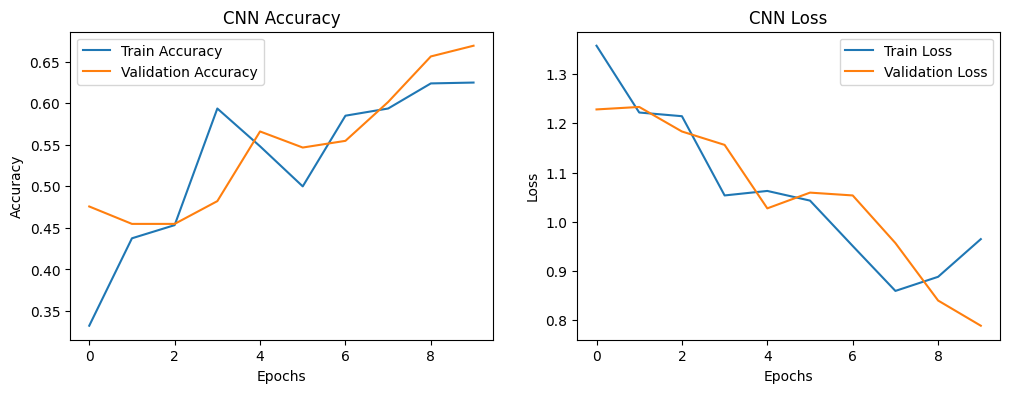

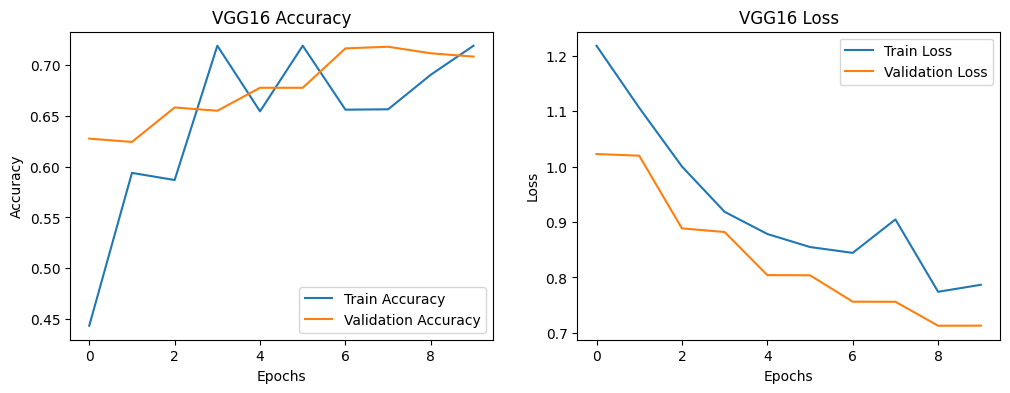

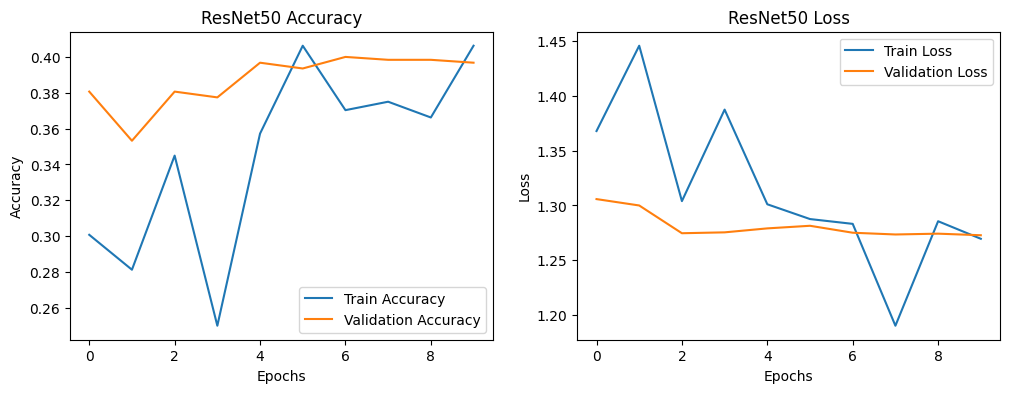

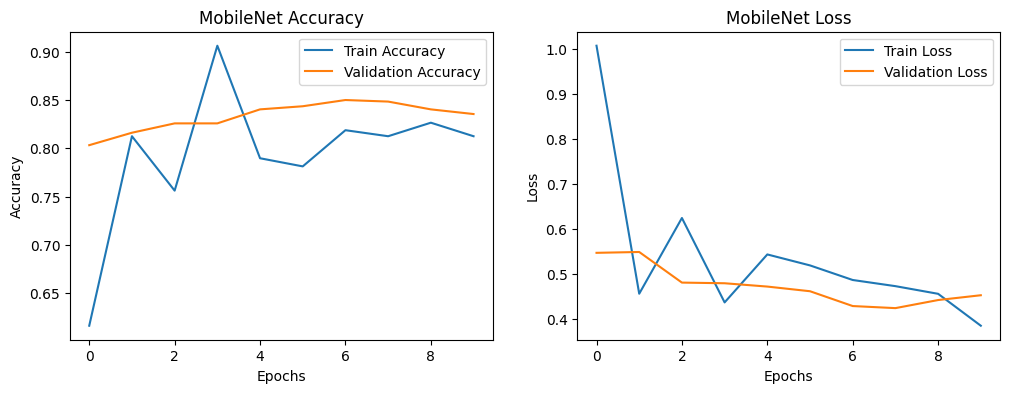

In [ ]:
import matplotlib.pyplot as plt



# Function to plot training and validation accuracy and loss

def plot_history(history, model_name):

    # Accuracy Plot

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)

    plt.plot(history.history['accuracy'], label='Train Accuracy')

    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{model_name} Accuracy')

    plt.xlabel('Epochs')

    plt.ylabel('Accuracy')

    plt.legend()



    # Loss Plot

    plt.subplot(1, 2, 2)

    plt.plot(history.history['loss'], label='Train Loss')

    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(f'{model_name} Loss')

    plt.xlabel('Epochs')

    plt.ylabel('Loss')

    plt.legend()



    plt.show()



# Plotting for each model

plot_history(history_cnn, "CNN")

plot_history(history_vgg16, "VGG16")

plot_history(history_resnet50, "ResNet50")

plot_history(history_mobilenet, "MobileNet")


In [ ]:
# Calculate validation accuracy for each model to determine weights

cnn_val_accuracy = cnn_model.evaluate(X_test, y_test, verbose=0)[1]

vgg16_val_accuracy = vgg16_model.evaluate(X_test, y_test, verbose=0)[1]

resnet50_val_accuracy = resnet50_model.evaluate(X_test, y_test, verbose=0)[1]

mobilenet_val_accuracy = mobilenet_model.evaluate(X_test, y_test, verbose=0)[1]



# Assign weights based on validation accuracy (normalize them to sum to 1)

total_accuracy = cnn_val_accuracy + vgg16_val_accuracy + resnet50_val_accuracy + mobilenet_val_accuracy

weights = [

    cnn_val_accuracy / total_accuracy,

    vgg16_val_accuracy / total_accuracy,

    resnet50_val_accuracy / total_accuracy,

    mobilenet_val_accuracy / total_accuracy

]



print("Model Weights based on validation accuracy:", weights)



# Weighted averaging ensemble

def weighted_ensemble_predict(models, weights, X):

    predictions = [model.predict(X) * weight for model, weight in zip(models, weights)]

    avg_prediction = np.sum(predictions, axis=0)

    return avg_prediction



# Use the weighted ensemble prediction on the test set

y_pred_weighted_ensemble = weighted_ensemble_predict(ensemble_models, weights, X_test)

y_pred_classes_weighted_ensemble = np.argmax(y_pred_weighted_ensemble, axis=1)



# Evaluate the Weighted Ensemble Model

weighted_ensemble_accuracy = accuracy_score(y_true, y_pred_classes_weighted_ensemble)

print(f"Weighted Ensemble Test Accuracy: {weighted_ensemble_accuracy * 100:.2f}%")



print("\nWeighted Ensemble Model Classification Report:")

print(classification_report(y_true, y_pred_classes_weighted_ensemble, target_names=categories))



print("\nWeighted Ensemble Model Confusion Matrix:")

print(confusion_matrix(y_true, y_pred_classes_weighted_ensemble))


Model Weights based on validation accuracy: [0.2564895013252995, 0.27132261458333895, 0.15203955935393962, 0.32014832473742194]
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Weighted Ensemble Test Accuracy: 82.10%

Weighted Ensemble Model Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.88      0.79      0.83       180
meningioma_tumor       0.81      0.69      0.74       183
          normal       0.87      0.84      0.86        88
 pituitary_tumor       0.77      0.98      0.86       169

        accuracy                           0.82       620
       macro avg       0.83      0.83      0.82       620
    weighted avg       0.83      0.82      0.82       620


Weighted Ensemble Model Confusion Matrix:
[[143  20   5  12]
 [ 15 126   6  36]
 [  5   7  74   2]
 [  0   3   0 166]]


In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import VotingClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline



# Create meta-features by predicting on the test set with each model

def get_meta_features(models, X):

    return np.array([model.predict(X) for model in models]).transpose((1, 0, 2)).reshape(X.shape[0], -1)



# Generate meta-features for the training and test sets

meta_X_train = get_meta_features(ensemble_models, X_train)

meta_X_test = get_meta_features(ensemble_models, X_test)



# Meta-learner

meta_learner = make_pipeline(StandardScaler(), LogisticRegression(max_iter=100))



# Train meta-learner on meta-features

y_train_labels = np.argmax(y_train, axis=1)

meta_learner.fit(meta_X_train, y_train_labels)



# Predict with meta-learner on test set

y_pred_meta = meta_learner.predict(meta_X_test)

stacking_accuracy = accuracy_score(y_true, y_pred_meta)

print(f"Stacking Ensemble Test Accuracy: {stacking_accuracy * 100:.2f}%")



print("\nStacking Ensemble Model Classification Report:")

print(classification_report(y_true, y_pred_meta, target_names=categories))



print("\nStacking Ensemble Model Confusion Matrix:")

print(confusion_matrix(y_true, y_pred_meta))


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Stacking Ensemble Test Accuracy: 85.48%

Stacking Ensemble Model Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.89      0.82      0.85       180
meningioma_tumor       0.77      0.81      0.79       183
          normal       0.94      0.85      0.89        88
 pituitary_tumor       0.88      0.93      0.91       169

        accuracy                           0.85       620
       macro avg       0.87      0.86      0.86       620
    weighted avg       0.86      0.85      0.86       620


Stacking Ensemble Model Confusion Matrix:
[[148  26   3   3]
 [ 14 149   2  18]
 [  5   7  75   1]
 [  0  11   0 158]]


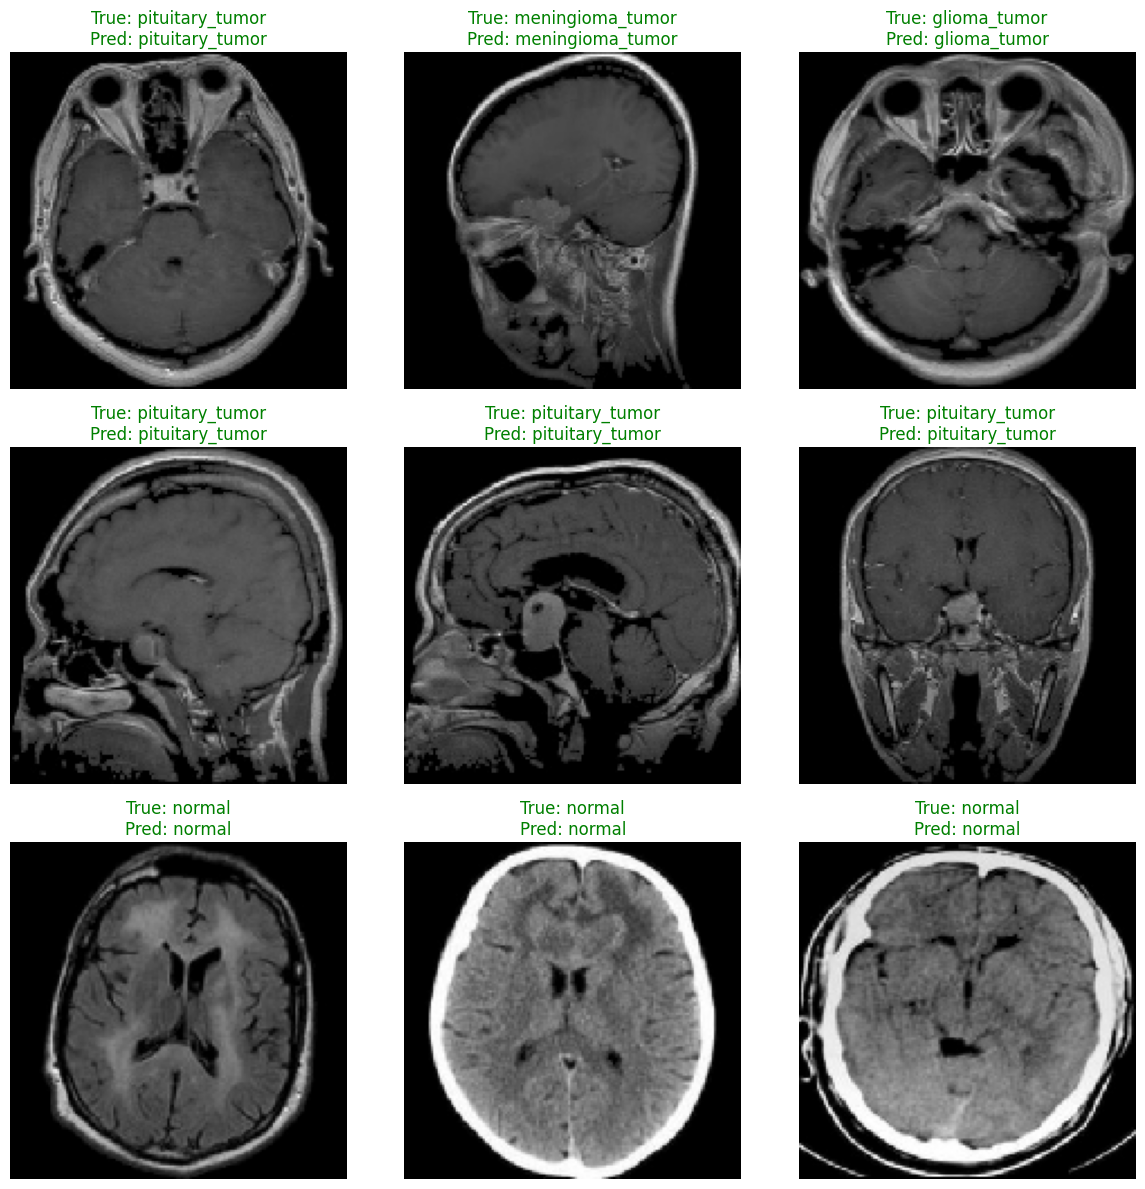

In [ ]:
import matplotlib.pyplot as plt



# Define a function to plot images with predictions and true labels

def plot_predictions(images, true_labels, pred_labels, categories, num_images=9):

    plt.figure(figsize=(12, 12))

    indices = np.random.choice(range(len(images)), num_images, replace=False)



    for i, idx in enumerate(indices):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[idx])

        true_label = categories[true_labels[idx]]

        pred_label = categories[pred_labels[idx]]



        # Set title color based on correct or incorrect prediction

        color = 'green' if true_label == pred_label else 'red'

        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)

        plt.axis('off')



    plt.tight_layout()

    plt.show()



# Get true labels and predictions from the ensemble model

y_true_labels = np.argmax(y_test, axis=1)

y_pred_classes_weighted_ensemble = np.argmax(y_pred_weighted_ensemble, axis=1)



# Plot a sample of test images with predictions

plot_predictions(X_test, y_true_labels, y_pred_classes_weighted_ensemble, categories)


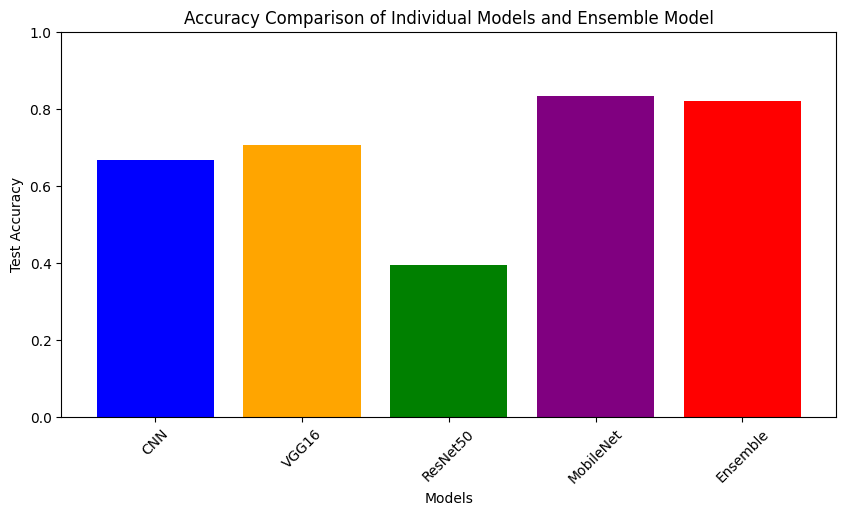

In [ ]:
import matplotlib.pyplot as plt



# Individual model accuracies

individual_accuracies = [

    cnn_val_accuracy,

    vgg16_val_accuracy,

    resnet50_val_accuracy,

    mobilenet_val_accuracy

]



# Append ensemble accuracy

model_names = ['CNN', 'VGG16', 'ResNet50', 'MobileNet', 'Ensemble']

accuracies = individual_accuracies + [weighted_ensemble_accuracy]



# Plotting the accuracy comparison

plt.figure(figsize=(10, 5))

plt.bar(model_names, accuracies, color=['blue', 'orange', 'green', 'purple', 'red'])

plt.title("Accuracy Comparison of Individual Models and Ensemble Model")

plt.xlabel("Models")

plt.ylabel("Test Accuracy")

plt.ylim(0, 1)  # Ensure the y-axis is scaled to show accuracy between 0 and 1 (or 0-100%)

plt.xticks(rotation=45)

plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


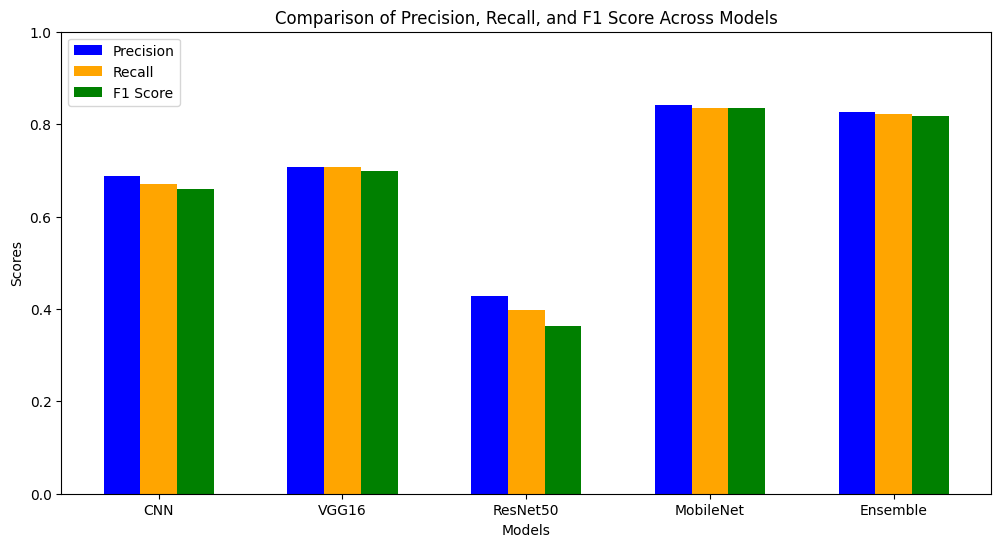

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score



# Define a function to get the key metrics for each model

def get_metrics(model, X_test, y_true, model_name):

    y_pred = model.predict(X_test)

    y_pred_classes = np.argmax(y_pred, axis=1)

    y_true_classes = np.argmax(y_true, axis=1)



    precision = precision_score(y_true_classes, y_pred_classes, average='weighted')

    recall = recall_score(y_true_classes, y_pred_classes, average='weighted')

    f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')



    return {'Model': model_name, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}



# Collect metrics for individual models

metrics = [

    get_metrics(cnn_model, X_test, y_test, 'CNN'),

    get_metrics(vgg16_model, X_test, y_test, 'VGG16'),

    get_metrics(resnet50_model, X_test, y_test, 'ResNet50'),

    get_metrics(mobilenet_model, X_test, y_test, 'MobileNet')

]



# Get ensemble model metrics

ensemble_precision = precision_score(y_true, y_pred_classes_weighted_ensemble, average='weighted')

ensemble_recall = recall_score(y_true, y_pred_classes_weighted_ensemble, average='weighted')

ensemble_f1 = f1_score(y_true, y_pred_classes_weighted_ensemble, average='weighted')



# Append ensemble metrics

metrics.append({'Model': 'Ensemble', 'Precision': ensemble_precision, 'Recall': ensemble_recall, 'F1 Score': ensemble_f1})



# Convert the metrics into lists for plotting

models = [metric['Model'] for metric in metrics]

precisions = [metric['Precision'] for metric in metrics]

recalls = [metric['Recall'] for metric in metrics]

f1_scores = [metric['F1 Score'] for metric in metrics]



# Plotting the metrics

import numpy as np



x = np.arange(len(models))  # label locations

width = 0.2  # width of the bars



plt.figure(figsize=(12, 6))

plt.bar(x - width, precisions, width, label='Precision', color='blue')

plt.bar(x, recalls, width, label='Recall', color='orange')

plt.bar(x + width, f1_scores, width, label='F1 Score', color='green')



plt.xlabel('Models')

plt.ylabel('Scores')

plt.title('Comparison of Precision, Recall, and F1 Score Across Models')

plt.xticks(x, models)

plt.ylim(0, 1)

plt.legend(loc='upper left')

plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


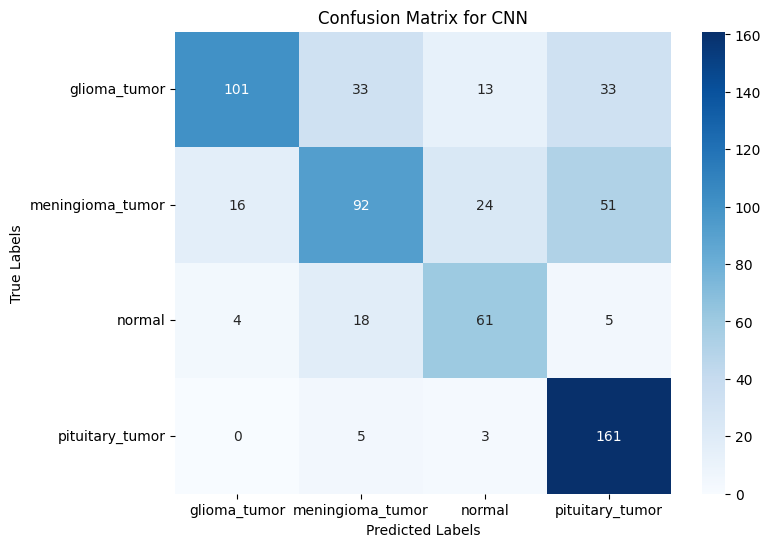

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


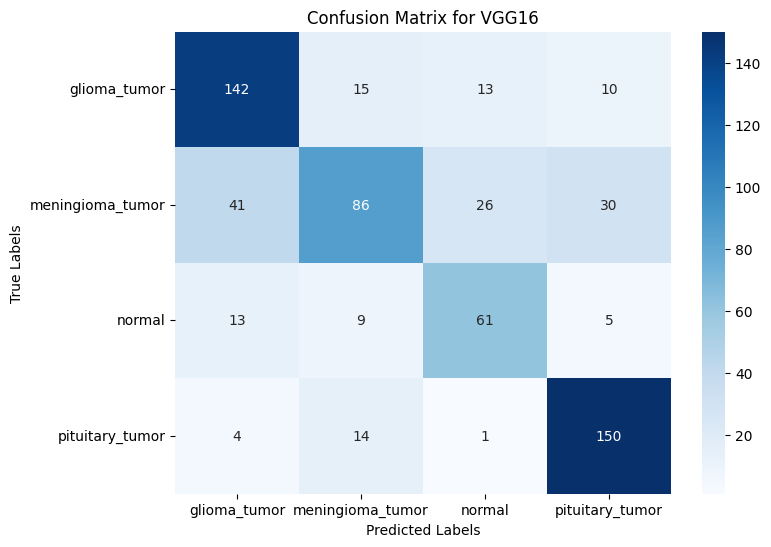

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


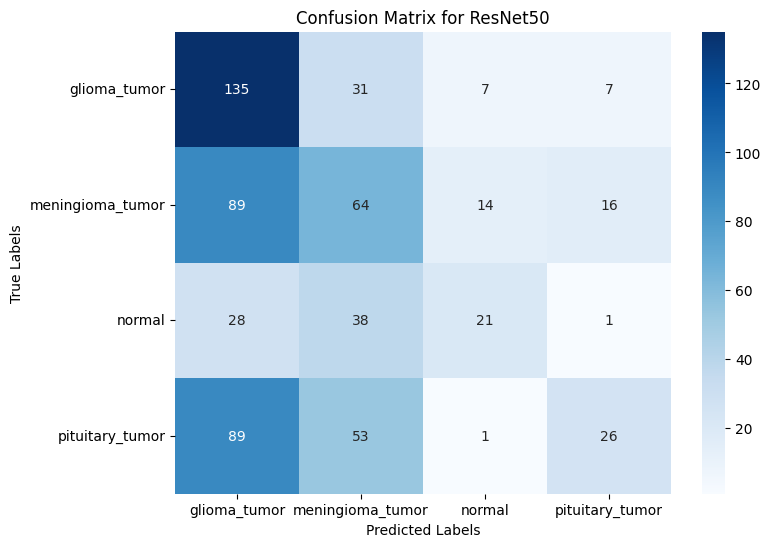

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


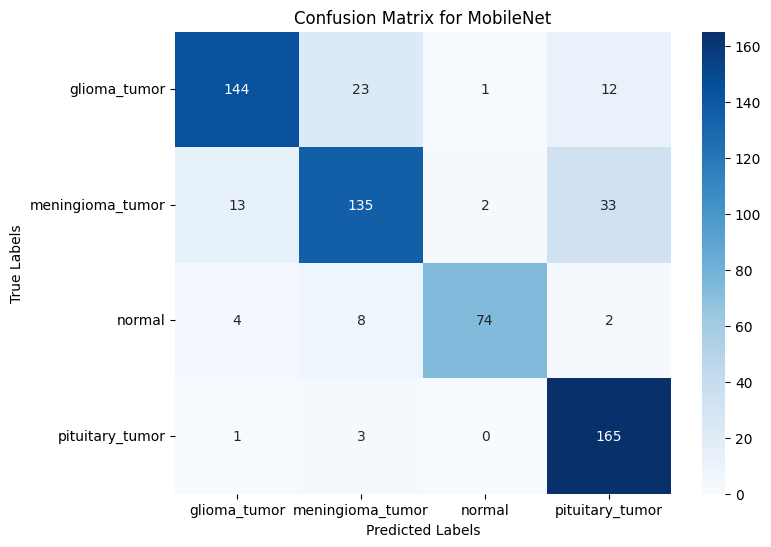

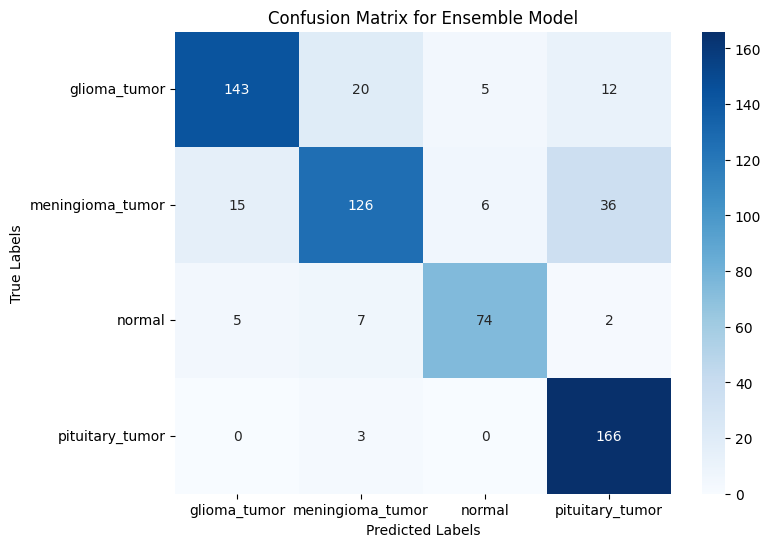

In [ ]:
import seaborn as sns

from sklearn.metrics import confusion_matrix



# Function to plot confusion matrix

def plot_confusion_matrix(y_true, y_pred, model_name, categories):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)

    plt.xlabel("Predicted Labels")

    plt.ylabel("True Labels")

    plt.title(f"Confusion Matrix for {model_name}")

    plt.show()



# True labels for the test set

y_true_classes = np.argmax(y_test, axis=1)



# Plot confusion matrices for individual models

plot_confusion_matrix(y_true_classes, np.argmax(cnn_model.predict(X_test), axis=1), 'CNN', categories)

plot_confusion_matrix(y_true_classes, np.argmax(vgg16_model.predict(X_test), axis=1), 'VGG16', categories)

plot_confusion_matrix(y_true_classes, np.argmax(resnet50_model.predict(X_test), axis=1), 'ResNet50', categories)

plot_confusion_matrix(y_true_classes, np.argmax(mobilenet_model.predict(X_test), axis=1), 'MobileNet', categories)



# Plot confusion matrix for the ensemble model

plot_confusion_matrix(y_true_classes, y_pred_classes_weighted_ensemble, 'Ensemble Model', categories)


In [ ]:
import matplotlib.pyplot as plt

import numpy as np



# Function to plot histograms for pixel intensity distributions

def plot_histograms(data, labels, categories):

    plt.figure(figsize=(12, 8))

    for i, category in enumerate(categories):

        category_data = data[np.argmax(labels, axis=1) == i]

        pixel_values = category_data.flatten()

        plt.hist(pixel_values, bins=50, alpha=0.6, label=category)



    plt.title("Pixel Intensity Distribution Across Classes")

    plt.xlabel("Pixel Intensity (Normalized)")

    plt.ylabel("Frequency")

    plt.legend(loc="upper right")

    plt.show()



# Function to visualize sample images from each category

def visualize_samples(data, labels, categories):

    plt.figure(figsize=(10, 10))

    for i, category in enumerate(categories):

        idx = np.where(np.argmax(labels, axis=1) == i)[0][0]

        plt.subplot(2, 2, i + 1)

        plt.imshow(data[idx])

        plt.title(category)

        plt.axis('off')

    plt.suptitle("Sample Images from Each Class")

    plt.show()



# Call the functions using the preprocessed data

plot_histograms(data, y_train, categories)

visualize_samples(data, y_train, categories)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


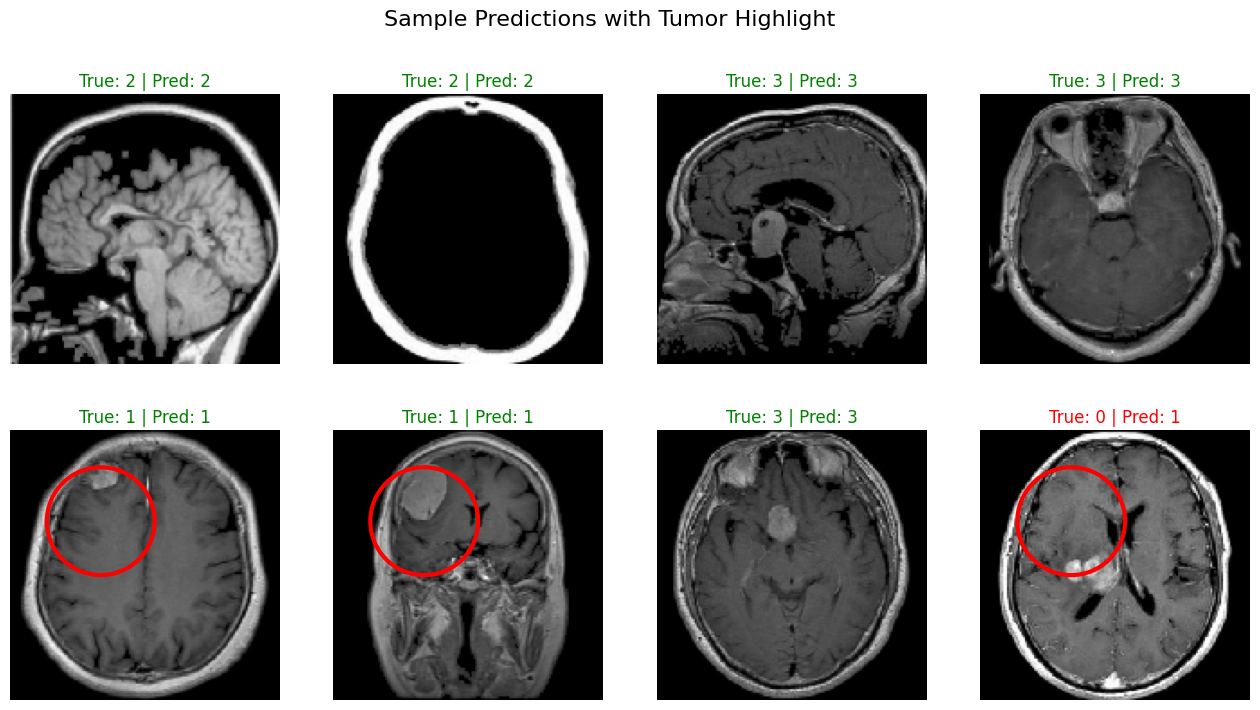

In [ ]:
import random

import matplotlib.pyplot as plt

from matplotlib.patches import Circle



# Define the label that corresponds to a tumor

# Adjust this value based on your dataset's label encoding (e.g., 1 for tumor, 0 for no tumor)

tumor_label = 1



# Number of images to display

num_display_images = 8

random_indices = random.sample(range(len(X_test)), num_display_images)

y_pred = np.argmax(mobilenet_model.predict(X_test), axis=1)



plt.figure(figsize=(16, 8))

for i, idx in enumerate(random_indices):

    plt.subplot(2, 4, i + 1)



    # Display the test image

    # Reshape to (150, 150) if the image is grayscale or keep (150, 150, 3) for color

    image_shape = X_test[idx].shape



    # Check if the image is grayscale or color

    if len(image_shape) == 3 and image_shape[-1] == 3: # Color Image

        plt.imshow(X_test[idx], cmap='gray') # Keep original shape for color images

    else:  # Grayscale Image (Assumed)

        plt.imshow(X_test[idx].reshape(150, 150), cmap='gray')  # Reshape to (150, 150) for grayscale



    # Prediction and true label

    pred_label = y_pred[idx] # Make sure y_pred is defined and accessible

    true_label = np.argmax(y_test[idx])  # Get the index of the true label (assuming one-hot encoding)



    # Add a red circle if the model predicts the image as a tumor

    if pred_label == tumor_label:

        ax = plt.gca()

        circle = Circle((50, 50), 30, color='red', fill=False, linewidth=3)  # Adjust position and radius if needed

        ax.add_patch(circle)



    # Display true and predicted labels

    plt.axis('off')

    # Compare the predicted label with the true label index

    plt.title(f"True: {true_label} | Pred: {pred_label}",

              color="green" if pred_label == true_label else "red")





plt.suptitle("Sample Predictions with Tumor Highlight", fontsize=16)

plt.show()

In [ ]:
from tf_keras_vis.gradcam import Gradcam

from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

from tf_keras_vis.utils.scores import CategoricalScore



def pinpoint_tumor(model, image, tumor_label):

    """

    Pinpoints the tumor in an image using Grad-CAM.



    Args:

        model: The trained Keras model.

        image: The input image.

        tumor_label: The label index corresponding to the tumor class.



    Returns:

        heatmap: The Grad-CAM heatmap.

    """



    # Create Gradcam object

    gradcam = Gradcam(model,

                      model_modifier=ReplaceToLinear(),

                      clone=True)



    # Generate heatmap with respect to the tumor class

    heatmap = gradcam(CategoricalScore(tumor_label),

                      image,

                      penultimate_layer=-1)  # Adjust penultimate_layer if needed



    # Print the shape of the heatmap (for debugging)

    print("Heatmap shape:", heatmap.shape)



    # Process the heatmap for visualization

    # (Normalize to 0-1 range and convert to RGB if necessary)

    heatmap = np.uint8(255 * heatmap)

    heatmap = heatmap / heatmap.max()



    return heatmap[0]  # Return the first heatmap (assuming batch size 1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


ValueError: No such layer: global_average_pooling2d. Existing layers are: ['mobilenet_1.00_224', 'global_average_pooling2d_2', 'dense_6', 'dropout_3', 'dense_7'].

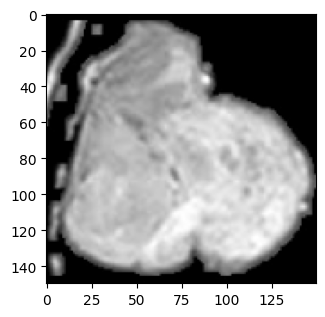

In [ ]:
import random

import numpy as np

import tensorflow as tf

import matplotlib.pyplot as plt

from matplotlib.patches import Circle

from skimage.transform import resize

from tf_keras_vis.gradcam import Gradcam

from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

from tf_keras_vis.utils.scores import CategoricalScore



# Define the label that corresponds to a tumor

tumor_label = 1  # Adjust this based on your dataset's label encoding (1 for tumor, 0 for no tumor)



# Number of images to display

num_display_images = 8

random_indices = random.sample(range(len(X_test)), num_display_images)



# Predict on the test data

y_pred = np.argmax(mobilenet_model.predict(X_test), axis=1)



# Define the Grad-CAM function for pinpointing the tumor

def pinpoint_tumor(model, image, tumor_label, input_shape=(150, 150)):

    """

    Pinpoints the tumor in an image using Grad-CAM.



    Args:

        model: The trained Keras model.

        image: The input image.

        tumor_label: The label index corresponding to the tumor class.

        input_shape: Shape of the input image.



    Returns:

        resized_heatmap: The resized heatmap to match the input image size.

    """

   # Select the layer before the final classification layer

    # For MobileNet, this is usually the 'global_average_pooling2d' layer

    penultimate_layer_name = 'global_average_pooling2d'  # Or 'avg_pool' depending on your model

    penultimate_layer = model.get_layer(penultimate_layer_name)



    # Create a new model with a single output from the penultimate layer

    grad_model = tf.keras.models.Model(inputs=model.inputs, outputs=penultimate_layer.output)



    # Initialize Grad-CAM with model modifications on the grad_model

    gradcam = Gradcam(grad_model, model_modifier=ReplaceToLinear(), clone=True)



    # Generate heatmap with respect to the tumor class

    heatmap = gradcam(CategoricalScore(tumor_label), image, penultimate_layer=-1)



    return resized_heatmap

# Plot the images with predictions and heatmaps

plt.figure(figsize=(16, 8))

for i, idx in enumerate(random_indices):

    plt.subplot(2, 4, i + 1)



    # Display the test image

    image_shape = X_test[idx].shape

    if len(image_shape) == 3 and image_shape[-1] == 3:  # Color image

        plt.imshow(X_test[idx])

    else:  # Grayscale image

        plt.imshow(X_test[idx].reshape(150, 150), cmap='gray')



    # Prediction and true label

    pred_label = y_pred[idx]

    true_label = np.argmax(y_test[idx])  # Assuming one-hot encoding for true label



    # Highlight tumor area with Grad-CAM and draw circle if tumor is detected

    if pred_label == tumor_label:

        # Generate resized heatmap using Grad-CAM

        heatmap = pinpoint_tumor(mobilenet_model, np.expand_dims(X_test[idx], axis=0), tumor_label)



        # Overlay the heatmap on the image

        plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay with transparency



        # Determine the highest activation point for circle positioning

        max_loc = np.unravel_index(np.argmax(heatmap), heatmap.shape)

        circle_radius = max(image_shape[0] // 10, 10)  # Set radius relative to image size for visibility

        circle = Circle((max_loc[1], max_loc[0]), circle_radius, color='red', fill=False, linewidth=2)

        plt.gca().add_patch(circle)



    # Display true and predicted labels

    plt.axis('off')

    plt.title(f"True: {true_label} | Pred: {pred_label}",

              color="green" if pred_label == true_label else "red")



plt.suptitle("Sample Predictions with Tumor Highlight", fontsize=16)

plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


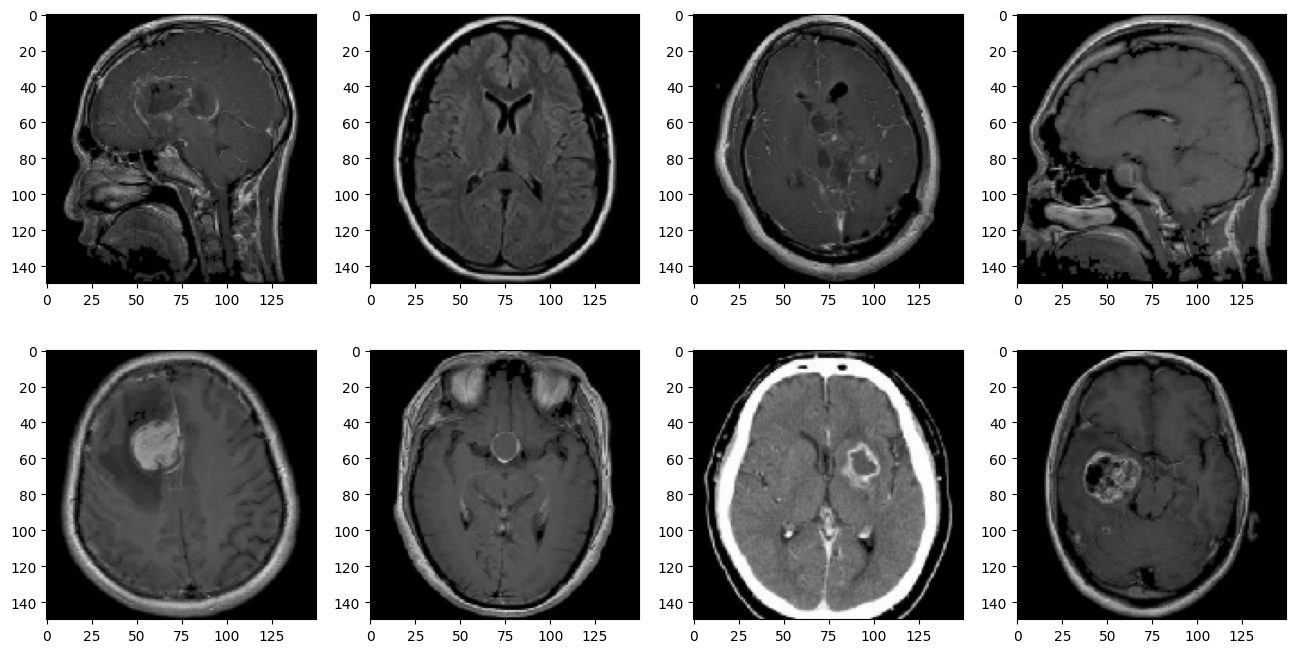

In [ ]:
import random

import numpy as np

import tensorflow as tf

import matplotlib.pyplot as plt

from matplotlib.patches import Circle

from skimage.transform import resize

from tf_keras_vis.gradcam import Gradcam

from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

from tf_keras_vis.utils.scores import CategoricalScore



# Define the label that corresponds to a tumor

tumor_label = 1  # Adjust this based on your dataset's label encoding (1 for tumor, 0 for no tumor)



# Number of images to display

num_display_images = 8

random_indices = random.sample(range(len(X_test)), num_display_images)



# Predict on the test data

y_pred = np.argmax(mobilenet_model.predict(X_test), axis=1)



# Define the Grad-CAM function for pinpointing the tumor

def pinpoint_tumor(model, image, tumor_label, input_shape=(150, 150)):

    """

    Pinpoints the tumor in an image using Grad-CAM.



    Args:

        model: The trained Keras model.

        image: The input image.

        tumor_label: The label index corresponding to the tumor class.

        input_shape: Shape of the input image.



    Returns:

        resized_heatmap: The resized heatmap to match the input image size.

    """

    # Select the layer before the final classification layer

    # For MobileNet, this is usually the 'global_average_pooling2d' layer

    # Corrected layer name based on the error message:

    penultimate_layer_name = 'global_average_pooling2d_2'  # Or 'avg_pool' depending on your model

    penultimate_layer = model.get_layer(penultimate_layer_name)



    # Create a new model with a single output from the penultimate layer

    grad_model = tf.keras.models.Model(inputs=model.inputs, outputs=penultimate_layer.output)



    # Initialize Grad-CAM with model modifications on the grad_model

    gradcam = Gradcam(grad_model, model_modifier=ReplaceToLinear(), clone=True)



    # Generate heatmap with respect to the tumor class

    heatmap = gradcam(CategoricalScore(tumor_label), image, penultimate_layer=-1)



    # Resize heatmap to match input image size (if necessary)

    resized_heatmap = resize(heatmap[0], input_shape)  # Assuming batch size 1



    return resized_heatmap



# Plot the images with predictions and heatmaps

plt.figure(figsize=(16, 8))

for i, idx in enumerate(random_indices):

    plt.subplot(2, 4, i + 1)



    # Display the test image

    image_shape = X_test[idx].shape

    if len(image_shape) == 3 and image_shape[-1] == 3:  # Color image

        plt.imshow(X_test[idx])

    else:  # Grayscale image

        plt.imshow(X_test[idx].reshape(150, 150), cmap='gray')



    # Prediction and true label

    pred_label = y_pred[idx]

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate, Input

from tensorflow.keras.models import Model



def unet_model(input_size=(128, 128, 1)):

    inputs = Input(input_size)



    # Contracting path (encoder)

    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)

    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)



    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)



    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)

    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)

    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)



    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)

    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)

    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)



    # Bottleneck

    conv5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(pool4)

    conv5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(conv5)



    # Expansive path (decoder)

    up6 = concatenate([UpSampling2D(size=(2, 2))(conv5), conv4], axis=-1)

    conv6 = Conv2D(512, (3, 3), activation='relu', padding='same')(up6)

    conv6 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv6)



    up7 = concatenate([UpSampling2D(size=(2, 2))(conv6), conv3], axis=-1)

    conv7 = Conv2D(256, (3, 3), activation='relu', padding='same')(up7)

    conv7 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv7)



    up8 = concatenate([UpSampling2D(size=(2, 2))(conv7), conv2], axis=-1)

    conv8 = Conv2D(128, (3, 3), activation='relu', padding='same')(up8)

    conv8 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv8)



    up9 = concatenate([UpSampling2D(size=(2, 2))(conv8), conv1], axis=-1)

    conv9 = Conv2D(64, (3, 3), activation='relu', padding='same')(up9)

    conv9 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv9)



    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv9)



    model = Model(inputs=[inputs], outputs=[outputs])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



    return model



# Initialize the U-Net model

unet = unet_model(input_size=(128, 128, 1))

unet.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 128, 128, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 64)   │            640 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 64, 64, 64)     │              0 │ conv2d_4[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 32, 32, 128)    │              0 │ conv2d_6[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 16, 16, 256)    │              0 │ conv2d_8[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 8, 8, 512)      │              0 │ conv2d_10[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_11[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 16, 16, 1024)   │              0 │ conv2d_12[0][0]        │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concaten

 Total params: 31,377,793 (119.70 MB)

 Trainable params: 31,377,793 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import cv2  # Import OpenCV for resizing

import numpy as np

import tensorflow as tf



# Reshape and normalize data using tf.image.resize for better compatibility with TensorFlow

X_train_resized = tf.image.resize(X_train, (128, 128))

X_train_resized = tf.image.rgb_to_grayscale(X_train_resized)  # Convert to grayscale

X_train_resized = X_train_resized / 255.0  # Normalize



# Assuming Y_train has shape (2476, 4) - one-hot encoded

# Convert Y_train to a segmentation mask if it's for segmentation

# For example, if the 2nd class represents the tumor:

Y_train_segmentation = np.zeros((Y_train.shape[0], 128, 128, 1))

for i in range(Y_train.shape[0]):

    # Check if the 2nd class (index 1) in Y_train is 1 (indicating tumor presence)

    if Y_train[i, 1] == 1:

        # Create a binary mask: 1 for tumor, 0 elsewhere.

        # Currently, it sets the entire image to 1 if a tumor is present in the label.

        # You might need to refine this based on how your ground truth masks are structured.

        Y_train_segmentation[i, :, :, 0] = 1

    else:

        Y_train_segmentation[i, :, :, 0] = 0



# Convert Y_train_segmentation to a TensorFlow tensor

Y_train_segmentation = tf.convert_to_tensor(Y_train_segmentation, dtype=tf.float32)



# Now use X_train_resized and Y_train_segmentation for training:

history = unet.fit(X_train_resized, Y_train_segmentation, validation_split=0.2, epochs=20, batch_size=16)

Epoch 1/20


AttributeError: 'NoneType' object has no attribute 'items'

In [ ]:
# Predict tumor segmentation on test set

predictions = unet.predict(X_test.reshape(-1, 128, 128, 1))



# Threshold predictions to get binary masks

predicted_masks = (predictions > 0.5).astype(int)


In [ ]:
import matplotlib.pyplot as plt



num_samples = 5  # Number of samples to display

plt.figure(figsize=(15, num_samples * 5))



for i in range(num_samples):

    plt.subplot(num_samples, 3, i * 3 + 1)

    plt.imshow(X_test[i].reshape(128, 128), cmap='gray')

    plt.title("Original Image")

    plt.axis('off')



    plt.subplot(num_samples, 3, i * 3 + 2)

    plt.imshow(Y_test[i].reshape(128, 128), cmap='gray')

    plt.title("Ground Truth Mask")

    plt.axis('off')



    plt.subplot(num_samples, 3, i * 3 + 3)

    plt.imshow(predicted_masks[i].reshape(128, 128), cmap='gray')

    plt.title("Predicted Mask")

    plt.axis('off')



plt.suptitle("Tumor Segmentation Results", fontsize=16)

plt.show()


In [ ]:
!unzip /content/braintumour